# 05.01 — Baseline Model
**Goal:** Train the first XGBoost model with default parameters.
Establish a performance baseline to beat in experiments.

**Train:** 2024 Won cohort
**Evaluate on:** 2025 Won cohort (decided labels only)

**Churn definition:** Post-renewal 4-week window — `Closed_Date` within 28 days after `Prospect_Renewal_Date`, `Prospect_Outcome = Churned` → label 1.


In [9]:
import sys, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, str(__import__('pathlib').Path.cwd().parents[1]))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from scipy import stats

from src.data.loader import load_all
from src.data.cleaner import clean_all

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 60)

PROJECT_ROOT = Path.cwd().parents[1]
FEATURES = PROJECT_ROOT / 'data' / 'features'
MODELS   = PROJECT_ROOT / 'models_saved'
REPORTS  = PROJECT_ROOT / 'reports' / 'figures'
REPORTS.mkdir(parents=True, exist_ok=True)

raw  = load_all()
data = clean_all(raw)
bills = data['billings']
cc    = data['cc_calls']
emails= data['emails']
rc    = data['renewal_calls']

print("All files loaded and cleaned.")
print(f"  billings:      {bills.shape}")
print(f"  cc_calls:      {cc.shape}")
print(f"  emails:        {emails.shape}")
print(f"  renewal_calls: {rc.shape}")

import json
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

from src.features.builder import get_feature_columns
from src.models.train import cross_validate, train_final_model, find_optimal_threshold, assign_risk_tier, DEFAULT_PARAMS
from src.models.evaluate import evaluate_model, plot_feature_importance, threshold_analysis, plot_calibration

FEATURES.mkdir(parents=True, exist_ok=True)
MODELS.mkdir(parents=True, exist_ok=True)


All files loaded and cleaned.
  billings:      (122082, 59)
  cc_calls:      (32882, 34)
  emails:        (123389, 28)
  renewal_calls: (186534, 41)


## Load Feature Tables

In [10]:

import pyarrow.parquet as pq

train_df = pd.read_parquet(FEATURES / 'train_2024.parquet')
test_df  = pd.read_parquet(FEATURES / 'test_2025.parquet')

with open(FEATURES / 'feature_cols.json') as f:
    feature_cols = json.load(f)

# Test set: only rows with decided labels
test_decided = test_df[test_df['churn_label'].notna()].copy()
test_decided['churn_label'] = test_decided['churn_label'].astype(int)

X_train = train_df[feature_cols]
y_train = train_df['churn_label'].astype(int)
X_test  = test_decided[feature_cols]
y_test  = test_decided['churn_label']

print(f"Training:  {X_train.shape} | churn={y_train.mean()*100:.2f}%")
print(f"Test:      {X_test.shape}  | churn={y_test.mean()*100:.2f}%")
print(f"Features:  {len(feature_cols)}")
print(f"scale_pos_weight: {(y_train==0).sum()/(y_train==1).sum():.1f}")


Training:  (6686, 60) | churn=13.98%
Test:      (6219, 60)  | churn=17.90%
Features:  60
scale_pos_weight: 6.2


## 5-Fold Cross-Validation on Training Set

In [11]:

print("Running 5-fold cross-validation...")
cv_results = cross_validate(X_train, y_train, params=DEFAULT_PARAMS, n_splits=5)


Running 5-fold cross-validation...
  Fold 1: PR-AUC=0.4512  ROC-AUC=0.8585  F1=0.5309
  Fold 2: PR-AUC=0.5877  ROC-AUC=0.8869  F1=0.5433
  Fold 3: PR-AUC=0.5374  ROC-AUC=0.8860  F1=0.5695
  Fold 4: PR-AUC=0.4964  ROC-AUC=0.8757  F1=0.5326
  Fold 5: PR-AUC=0.4799  ROC-AUC=0.8614  F1=0.5147

  CV Summary (5-fold):
  PR-AUC  = 0.5105 ± 0.0476
  ROC-AUC = 0.8737 ± 0.0119
  F1      = 0.5382 ± 0.0181


## Train Final Baseline Model

In [12]:

model_v1 = train_final_model(
    X_train, y_train,
    X_val=X_test, y_val=y_test,
    params=DEFAULT_PARAMS,
    model_name='churn_model_v1_baseline'
)


[0]	validation_0-aucpr:0.45143
[50]	validation_0-aucpr:0.57940
[100]	validation_0-aucpr:0.59113
[150]	validation_0-aucpr:0.59348
[200]	validation_0-aucpr:0.59006
[250]	validation_0-aucpr:0.58878
[300]	validation_0-aucpr:0.58783
[350]	validation_0-aucpr:0.58482
[399]	validation_0-aucpr:0.58086
Model saved → C:\ds-project\post_renewal_churn_prediction\models_saved\churn_model_v1_baseline.json


## Evaluate on Test Set

Model Evaluation — v1_baseline
  Threshold used:    0.534
  PR-AUC:            0.5815
  ROC-AUC:           0.8701
  Precision:         0.5277
  Recall:            0.6586
  F1:                0.5859

  Total test customers:  6,219
  Actual churners:       1,113
  Customers flagged:     1,389
  Churners caught:       733 (65.9%)
  Churners missed:       380

              precision    recall  f1-score   support

    Retained       0.92      0.87      0.90      5106
     Churned       0.53      0.66      0.59      1113

    accuracy                           0.83      6219
   macro avg       0.72      0.77      0.74      6219
weighted avg       0.85      0.83      0.84      6219



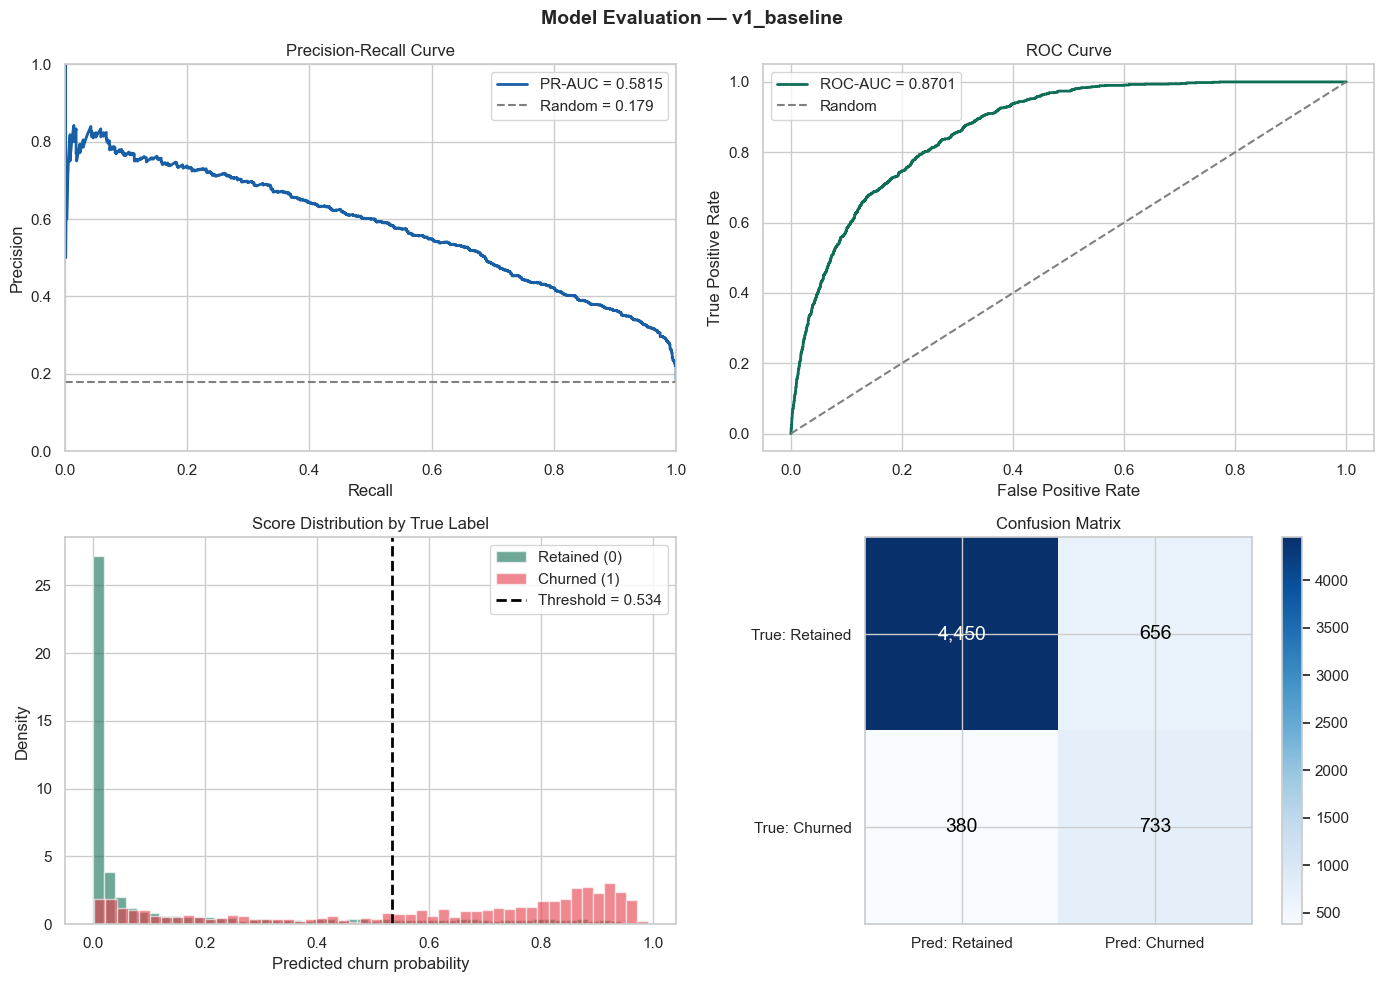

Plot saved → C:\ds-project\post_renewal_churn_prediction\reports\figures\v1_baseline_evaluation.png


In [13]:

baseline_metrics = evaluate_model(
    model_v1, X_test, y_test,
    model_name='v1_baseline',
    save_plots=True
)


## Feature Importance

Saved → C:\ds-project\post_renewal_churn_prediction\reports\figures\v1_baseline_feature_importance.png


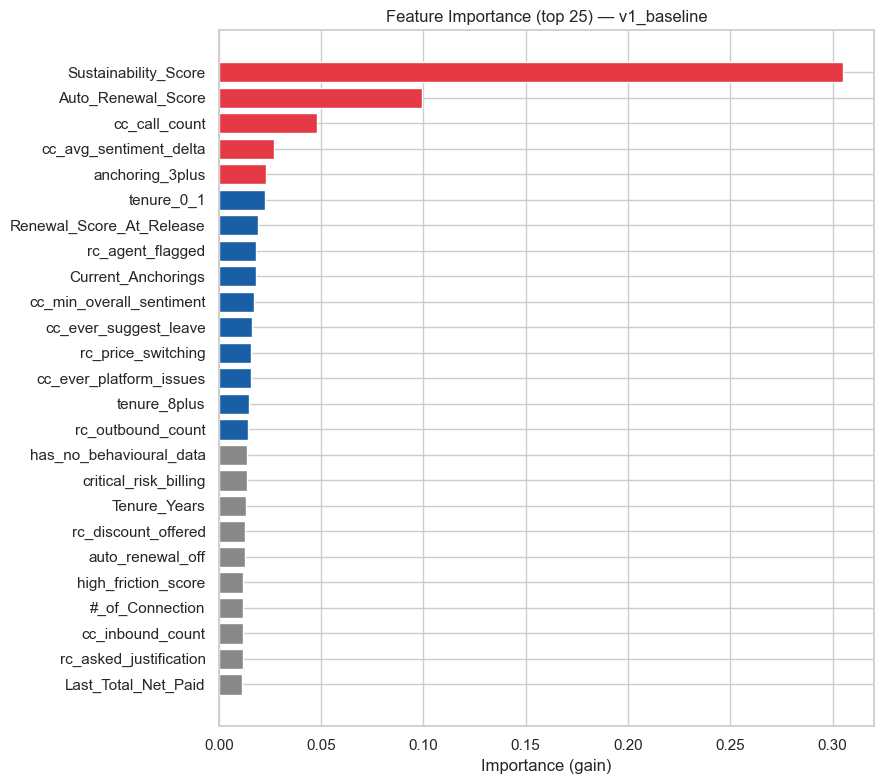


Top 15 features:
                 feature  importance
    Sustainability_Score      0.3050
      Auto_Renewal_Score      0.0992
           cc_call_count      0.0480
  cc_avg_sentiment_delta      0.0272
         anchoring_3plus      0.0230
              tenure_0_1      0.0228
Renewal_Score_At_Release      0.0189
        rc_agent_flagged      0.0182
      Current_Anchorings      0.0181
cc_min_overall_sentiment      0.0174
   cc_ever_suggest_leave      0.0160
      rc_price_switching      0.0156
 cc_ever_platform_issues      0.0155
            tenure_8plus      0.0147
       rc_outbound_count      0.0141


In [14]:

fi_df = plot_feature_importance(model_v1, feature_cols, top_n=25, model_name='v1_baseline')
print("\nTop 15 features:")
print(fi_df.head(15).to_string(index=False))


## Threshold Analysis — Business Tradeoff

Precision/Recall at different thresholds:
 threshold  precision  recall     f1  flagged  caught
    0.0500     0.3520  0.9120 0.5080     2886    1015
    0.1000     0.3800  0.8620 0.5270     2526     959
    0.1500     0.4010  0.8360 0.5420     2321     930
    0.2000     0.4150  0.8030 0.5470     2154     894
    0.2500     0.4320  0.7780 0.5550     2006     866
    0.3000     0.4430  0.7540 0.5580     1896     839
    0.3500     0.4570  0.7310 0.5620     1782     814
    0.4000     0.4710  0.7160 0.5680     1692     797
    0.4500     0.4890  0.6930 0.5730     1576     771
    0.5000     0.5140  0.6770 0.5840     1468     754


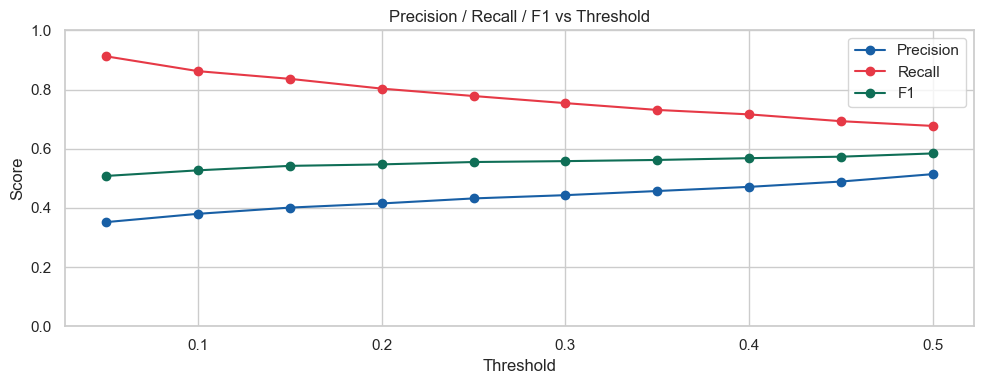

In [15]:

proba = model_v1.predict_proba(X_test)[:,1]
print("Precision/Recall at different thresholds:")
thresh_df = threshold_analysis(y_test.values, proba)

# Plot
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresh_df['threshold'], thresh_df['precision'], 'o-', color='#185FA5', label='Precision')
ax.plot(thresh_df['threshold'], thresh_df['recall'],    'o-', color='#E63946', label='Recall')
ax.plot(thresh_df['threshold'], thresh_df['f1'],        'o-', color='#0F6E56', label='F1')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 vs Threshold')
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(REPORTS / 'v1_threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


## Calibration Check

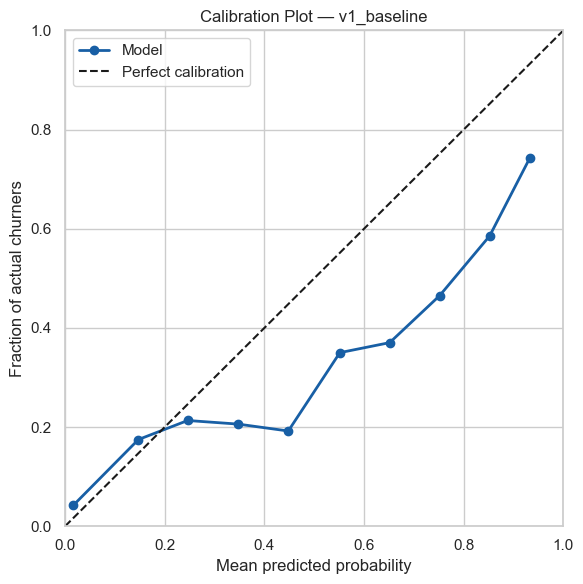

Saved → C:\ds-project\post_renewal_churn_prediction\reports\figures\v1_baseline_calibration.png


In [16]:

plot_calibration(y_test.values, proba, model_name='v1_baseline')
